# Example 02: Cohesive Zone Interface Modeling

## Overview
This notebook demonstrates cohesive zone modeling for a bi-material interface using the **pyGmsh + OpenSeesPy** pipeline.

### Problem Description
Two rectangular material blocks (e.g., concrete-to-concrete bonded joint) are stacked vertically with a shared interface. The interface is modeled using OpenSees `zeroLength` elements with cohesive-like material response, enabling simulation of interface debonding under tensile loading.

### Key Concepts
- **Conformal meshing**: Two separate blocks meshed with matching node spacing at the interface
- **Node pairing**: Identify corresponding nodes on each block's interface surface
- **zeroLength elements**: Connect paired interface nodes with nonlinear cohesive materials
- **Cohesive material**: Penalty-based stiffness (normal and shear) with tensile/shear strength limits

### Workflow
1. Define geometry: two rectangles with conformal mesh spacing
2. Mesh with structured quad elements
3. Extract and pair interface nodes
4. Build OpenSees model with bulk elements and zeroLength cohesive interface
5. Run Mode-I opening test with displacement control
6. Post-process: traction-separation curves and deformed shapes

In [1]:
from pyGmsh import pyGmsh
from pyGmsh import Algorithm2D
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gmsh

# Optional: try to import openseespy for analysis
try:
    import openseespy.opensees as ops
    OPENSEES_AVAILABLE = True
except ImportError:
    OPENSEES_AVAILABLE = False
    print("Warning: openseespy not available. Analysis will be skipped.")

## Parameters: Geometry & Material Properties

In [2]:
# ── Geometry parameters ──────────────────────────────────────
L1 = 1.0        # Length of block 1 (bottom) [m]
H1 = 0.5        # Height of block 1 [m]

L2 = 1.0        # Length of block 2 (top) [m]
H2 = 0.5        # Height of block 2 [m]

y_interface = H1  # Y-coordinate of interface (top of block 1)

# ── Mesh parameters ──────────────────────────────────────
lc = 0.05       # Target characteristic element size [m]
t = 1.0         # Thickness (plane stress) [m]

# ── Material parameters (both blocks) ──────────────────
E = 30e9        # Young's modulus [Pa]
nu = 0.20       # Poisson's ratio [-]

# ── Interface/Cohesive parameters ──────────────────────
Kn = 1e12       # Normal stiffness at interface [N/m³] (penalty-like)
Ks = 1e11       # Shear stiffness at interface [N/m³]
ft = 3e6        # Tensile strength (opening) [Pa]
fs = 5e6        # Shear strength (sliding) [Pa]

# ── Loading parameters ────────────────────────────────
max_displacement = 1e-3  # Max opening displacement [m]
n_steps = 50             # Number of load steps

print(f"Block 1 (bottom): L={L1} m, H={H1} m")
print(f"Block 2 (top):    L={L2} m, H={H2} m")
print(f"Interface at y = {y_interface} m")
print(f"Mesh size: lc={lc} m")
print(f"Material: E={E/1e9} GPa, nu={nu}")
print(f"Interface: Kn={Kn:.1e} N/m³, ft={ft/1e6} MPa"
)

Block 1 (bottom): L=1.0 m, H=0.5 m
Block 2 (top):    L=1.0 m, H=0.5 m
Interface at y = 0.5 m
Mesh size: lc=0.05 m
Material: E=30.0 GPa, nu=0.2
Interface: Kn=1.0e+12 N/m³, ft=3.0 MPa


## Geometry: Two Blocks with Shared Interface

We create two rectangular blocks that share the interface at y = H1.
The key is to use **separate surfaces** with **conformal meshing** so that 
nodes on the interface from each block are aligned (same x-coordinates).
This allows us to pair nodes and insert zeroLength elements between them.

In [3]:
# Initialize gmsh context
with pyGmsh(model_name="CohesiveZone", verbose=False) as g:
    
    # ── Block 1 (bottom) ──────────────────────────────────────
    p1_b1 = g.model.add_point(0.0, 0.0, 0.0, lc=lc)
    p2_b1 = g.model.add_point(L1, 0.0, 0.0, lc=lc)
    p3_b1 = g.model.add_point(L1, H1, 0.0, lc=lc)
    p4_b1 = g.model.add_point(0.0, H1, 0.0, lc=lc)
    
    l1_b1 = g.model.add_line(p1_b1, p2_b1)  # bottom
    l2_b1 = g.model.add_line(p2_b1, p3_b1)  # right
    l3_b1 = g.model.add_line(p3_b1, p4_b1)  # top (interface)
    l4_b1 = g.model.add_line(p4_b1, p1_b1)  # left
    
    loop_b1 = g.model.add_curve_loop([l1_b1, l2_b1, l3_b1, l4_b1])
    surf_b1 = g.model.add_plane_surface(loop_b1)
    
    # ── Block 2 (top) ────────────────────────────────────────
    # Start at the interface level (y = H1)
    p1_b2 = g.model.add_point(0.0, H1, 0.0, lc=lc)
    p2_b2 = g.model.add_point(L2, H1, 0.0, lc=lc)
    p3_b2 = g.model.add_point(L2, H1 + H2, 0.0, lc=lc)
    p4_b2 = g.model.add_point(0.0, H1 + H2, 0.0, lc=lc)
    
    l1_b2 = g.model.add_line(p1_b2, p2_b2)  # bottom (interface)
    l2_b2 = g.model.add_line(p2_b2, p3_b2)  # right
    l3_b2 = g.model.add_line(p3_b2, p4_b2)  # top
    l4_b2 = g.model.add_line(p4_b2, p1_b2)  # left
    
    loop_b2 = g.model.add_curve_loop([l1_b2, l2_b2, l3_b2, l4_b2])
    surf_b2 = g.model.add_plane_surface(loop_b2)
    
    g.model.sync()
    
    # ── Physical groups ──────────────────────────────────────
    (g.physical
        .add_surface([surf_b1], name="Block1")
        .add_surface([surf_b2], name="Block2")
        .add_curve([l3_b1], name="Interface_B1")  # top edge of block 1
        .add_curve([l1_b2], name="Interface_B2")  # bottom edge of block 2
        .add_curve([l4_b1], name="LeftEdge_B1")   # for possible BCs
        .add_curve([l4_b2], name="LeftEdge_B2"))
    
    print("Geometry created:")
    print(f"  Block 1 surface tag: {surf_b1}")
    print(f"  Block 2 surface tag: {surf_b2}")
    print(f"  Interface curve (B1 top): {l3_b1}")
    print(f"  Interface curve (B2 bottom): {l1_b2}")
    
    # Save the pyGmsh object for reuse in next cell
    # (Note: we'll recreate it in the mesh cell for cleaner execution)

Geometry created:
  Block 1 surface tag: 1
  Block 2 surface tag: 2
  Interface curve (B1 top): 3
  Interface curve (B2 bottom): 5


## Meshing with Conformal Interface

We use **structured quad meshing** on both blocks with the same characteristic length.
This ensures:
1. Node alignment at the interface (same x-coordinates)
2. Matching number of interface nodes for pairing
3. Better element quality for FEM analysis

In [4]:
# Recreate geometry and mesh in one unified operation
with pyGmsh(model_name="CohesiveZone", verbose=False) as g:
    
    # ── Geometry ──────────────────────────────────────────
    p1_b1 = g.model.add_point(0.0, 0.0, 0.0, lc=lc)
    p2_b1 = g.model.add_point(L1, 0.0, 0.0, lc=lc)
    p3_b1 = g.model.add_point(L1, H1, 0.0, lc=lc)
    p4_b1 = g.model.add_point(0.0, H1, 0.0, lc=lc)
    
    l1_b1 = g.model.add_line(p1_b1, p2_b1)
    l2_b1 = g.model.add_line(p2_b1, p3_b1)
    l3_b1 = g.model.add_line(p3_b1, p4_b1)
    l4_b1 = g.model.add_line(p4_b1, p1_b1)
    
    loop_b1 = g.model.add_curve_loop([l1_b1, l2_b1, l3_b1, l4_b1])
    surf_b1 = g.model.add_plane_surface(loop_b1)
    
    p1_b2 = g.model.add_point(0.0, H1, 0.0, lc=lc)
    p2_b2 = g.model.add_point(L2, H1, 0.0, lc=lc)
    p3_b2 = g.model.add_point(L2, H1 + H2, 0.0, lc=lc)
    p4_b2 = g.model.add_point(0.0, H1 + H2, 0.0, lc=lc)
    
    l1_b2 = g.model.add_line(p1_b2, p2_b2)
    l2_b2 = g.model.add_line(p2_b2, p3_b2)
    l3_b2 = g.model.add_line(p3_b2, p4_b2)
    l4_b2 = g.model.add_line(p4_b2, p1_b2)
    
    loop_b2 = g.model.add_curve_loop([l1_b2, l2_b2, l3_b2, l4_b2])
    surf_b2 = g.model.add_plane_surface(loop_b2)
    
    # ── Fragment to enforce conformal interface mesh ──────
    # Without fragment(), OCC keeps the two surfaces independent
    # and their meshes at y=H1 would NOT be conformal.
    out, out_map = gmsh.model.occ.fragment(
        [(2, surf_b1)], [(2, surf_b2)]
    )
    gmsh.model.occ.synchronize()
    
    # After fragment, surf_b1/surf_b2 tags may have changed.
    # out_map[0] → entities from the first object  (Block 1)
    # out_map[1] → entities from the second object (Block 2)
    frag_b1_surfs = [t for d, t in out_map[0] if d == 2]
    frag_b2_surfs = [t for d, t in out_map[1] if d == 2]
    
    print(f"After fragment: Block1 surfaces={frag_b1_surfs}, Block2 surfaces={frag_b2_surfs}")
    
    # ── Physical groups ──────────────────────────────────
    (g.physical
        .add_surface(frag_b1_surfs, name="Block1")
        .add_surface(frag_b2_surfs, name="Block2"))
    
    # ── Meshing ───────────────────────────────────────────
    (g.mesh
        .set_global_size(lc)
        .set_algorithm(2, Algorithm2D.AUTOMATIC, dim=2)
        .generate(2))
    
    # ── Extract and persist ALL mesh data before context closes ──
    all_node_tags, all_node_coords, _ = gmsh.model.mesh.getNodes()
    all_node_coords = all_node_coords.reshape(-1, 3)
    
    # Per-surface element data
    _, b1_etags_list, b1_enodes_list = gmsh.model.mesh.getElements(2, frag_b1_surfs[0])
    _, b2_etags_list, b2_enodes_list = gmsh.model.mesh.getElements(2, frag_b2_surfs[0])
    
    # Global element data
    elem_types_raw, elem_tags_raw, elem_nodes_raw = gmsh.model.mesh.getElements(dim=2)
    
    # Persist as globals
    gmsh_nodes         = all_node_coords
    gmsh_node_tags     = all_node_tags
    gmsh_elem_types    = elem_types_raw
    gmsh_elem_tags     = elem_tags_raw
    gmsh_elem_nodes    = elem_nodes_raw
    gmsh_b1_elem_tags  = b1_etags_list
    gmsh_b1_elem_nodes = b1_enodes_list
    gmsh_b2_elem_tags  = b2_etags_list
    gmsh_b2_elem_nodes = b2_enodes_list
    
    n_b1_elems = sum(len(t) for t in b1_etags_list)
    n_b2_elems = sum(len(t) for t in b2_etags_list)
    
    print(f"Mesh generation complete:")
    print(f"  Total nodes: {len(all_node_tags)}")
    print(f"  Element types: {elem_types_raw}")
    print(f"  Block 1 elements: {n_b1_elems}")
    print(f"  Block 2 elements: {n_b2_elems}")
    print(f"  Total elements: {sum(len(t) for t in elem_tags_raw)}")

After fragment: Block1 surfaces=[1], Block2 surfaces=[2]
Mesh generation complete:
  Total nodes: 542
  Element types: [2]
  Block 1 elements: 486
  Block 2 elements: 516
  Total elements: 1002


## Interface Node Pairing

To model the cohesive interface, we need to:
1. Identify nodes on the interface from Block 1 (y ≈ H1)
2. Identify nodes on the interface from Block 2 (y ≈ H1)
3. Match pairs by x-coordinate proximity
4. These pairs will be connected by zeroLength elements

Since pyGmsh creates conformal nodes at shared edges, we manually extract
and pair nodes based on spatial proximity.

In [5]:
# ── Interface node duplication for cohesive zone ──────────────────
#
# After fragment(), both blocks share the same nodes at the interface
# (y ≈ H1).  For a cohesive zone we:
#   1. Collect node IDs referenced by each block's elements
#   2. Find the SHARED nodes at y ≈ H1 (these are the interface)
#   3. Duplicate those nodes with new IDs for Block 2
#   4. Rewire Block 2 connectivity to use the duplicates
#   5. Build (original, duplicate) pairs for zeroLength elements

tol_interface = 1e-4
y_interface = H1

# Build coordinate lookup  {node_id: (x, y, z)}
coord_map = {int(gmsh_node_tags[i]): gmsh_nodes[i]
             for i in range(len(gmsh_node_tags))}

# Collect node IDs used by each block's elements
b1_node_ids = set()
for enodes in gmsh_b1_elem_nodes:
    b1_node_ids.update(int(n) for n in enodes)

b2_node_ids = set()
for enodes in gmsh_b2_elem_nodes:
    b2_node_ids.update(int(n) for n in enodes)

# Shared interface nodes: referenced by BOTH blocks AND at y ≈ H1
shared_interface = sorted(
    nid for nid in (b1_node_ids & b2_node_ids)
    if abs(coord_map[nid][1] - y_interface) < tol_interface
)

print(f"Block 1 nodes: {len(b1_node_ids)}")
print(f"Block 2 nodes: {len(b2_node_ids)}")
print(f"Shared interface nodes at y={y_interface}: {len(shared_interface)}")

# Create duplicate nodes: new_id = max_existing + 1, 2, ...
next_id = int(gmsh_node_tags.max()) + 1
old_to_new = {}           # original_id → duplicate_id
dup_coords = {}           # duplicate_id → (x, y, z)

for nid in shared_interface:
    old_to_new[nid] = next_id
    dup_coords[next_id] = coord_map[nid]
    next_id += 1

print(f"Duplicated nodes: {len(old_to_new)}  (IDs {min(old_to_new.values())}–{max(old_to_new.values())})")

# Re-wire Block 2 element connectivity to use duplicated nodes
b2_elem_nodes_fixed = []
for enodes in gmsh_b2_elem_nodes:
    arr = enodes.copy()
    for idx in range(len(arr)):
        nid = int(arr[idx])
        if nid in old_to_new:
            arr[idx] = old_to_new[nid]
    b2_elem_nodes_fixed.append(arr)

# Build interface pairs  [(block1_id, block2_dup_id), ...]
interface_pairs = []
for orig, dup in sorted(old_to_new.items()):
    interface_pairs.append({
        'node1': orig,       # Block 1 side (original)
        'node2': dup,        # Block 2 side (duplicate)
        'x': coord_map[orig][0],
    })

print(f"\nInterface node pairs: {len(interface_pairs)}")
if interface_pairs:
    print(f"  First pair: {interface_pairs[0]['node1']} ↔ {interface_pairs[0]['node2']}")
    print(f"  Last pair:  {interface_pairs[-1]['node1']} ↔ {interface_pairs[-1]['node2']}")

Block 1 nodes: 274
Block 2 nodes: 289
Shared interface nodes at y=0.5: 21
Duplicated nodes: 21  (IDs 543–563)

Interface node pairs: 21
  First pair: 3 ↔ 543
  Last pair:  53 ↔ 563


## OpenSees Model Setup

We build an OpenSees model with:
1. **Bulk elements**: quad elements for each block (using g.opensees)
2. **Interface elements**: zeroLength elements connecting paired nodes

Since OpenSees zeroLength elements are not directly exposed in pyGmsh's OpenSees module,
we'll export the bulk mesh and then post-process to add zeroLength elements.

In [6]:
if not OPENSEES_AVAILABLE:
    print("Skipping OpenSees model build: openseespy not available")
else:
    try:
        # Initialize OpenSees model
        ops.wipe()
        ops.model('basic', '-ndm', 2, '-ndf', 2)
        
        # ── Create original nodes ─────────────────────────────
        for i, node_id in enumerate(gmsh_node_tags):
            x, y, z = gmsh_nodes[i]
            ops.node(int(node_id), x, y)
        
        # ── Create duplicated interface nodes (Block 2 side) ──
        for dup_id, (x, y, z) in dup_coords.items():
            ops.node(dup_id, x, y)
        
        n_total = len(gmsh_node_tags) + len(dup_coords)
        print(f"Created {n_total} nodes ({len(gmsh_node_tags)} original + {len(dup_coords)} duplicated)")
        
        # ── Create materials ──────────────────────────────────
        mat_bulk = 1
        ops.nDMaterial('ElasticIsotropic', mat_bulk, E, nu)
        
        mat_cohesive_n = 2
        ops.uniaxialMaterial('Elastic', mat_cohesive_n, Kn)
        
        mat_cohesive_s = 3
        ops.uniaxialMaterial('Elastic', mat_cohesive_s, Ks)
        
        print(f"Created materials: bulk({mat_bulk}), cohesive_n({mat_cohesive_n}), cohesive_s({mat_cohesive_s})")
        
        # ── Create bulk elements for Block 1 (original nodes) ─
        elem_id = 1
        for etags, enodes in zip(gmsh_b1_elem_tags, gmsh_b1_elem_nodes):
            n_per_elem = len(enodes) // len(etags)
            connectivity = enodes.reshape(-1, n_per_elem)
            for node_set in connectivity:
                ns = [int(n) for n in node_set]
                if n_per_elem == 4:
                    ops.element('quad', elem_id, *ns, t, 'PlaneStress', mat_bulk)
                elif n_per_elem == 3:
                    ops.element('tri31', elem_id, *ns, t, 'PlaneStress', mat_bulk)
                elem_id += 1
        
        n_b1 = elem_id - 1
        
        # ── Create bulk elements for Block 2 (with remapped nodes) ─
        for etags, enodes in zip(gmsh_b2_elem_tags, b2_elem_nodes_fixed):
            n_per_elem = len(enodes) // len(etags)
            connectivity = enodes.reshape(-1, n_per_elem)
            for node_set in connectivity:
                ns = [int(n) for n in node_set]
                if n_per_elem == 4:
                    ops.element('quad', elem_id, *ns, t, 'PlaneStress', mat_bulk)
                elif n_per_elem == 3:
                    ops.element('tri31', elem_id, *ns, t, 'PlaneStress', mat_bulk)
                elem_id += 1
        
        n_bulk = elem_id - 1
        print(f"Created {n_bulk} bulk elements (B1: {n_b1}, B2: {n_bulk - n_b1})")
        
        # ── Create zeroLength elements at interface ───────────
        zl_count = 0
        zl_elem_id = 10000
        
        for pair in interface_pairs:
            n1 = pair['node1']   # Block 1 original
            n2 = pair['node2']   # Block 2 duplicate
            
            ops.element('zeroLength', zl_elem_id, n1, n2,
                        '-mat', mat_cohesive_s, mat_cohesive_n,
                        '-dir', 1, 2)
            zl_elem_id += 1
            zl_count += 1
        
        print(f"Created {zl_count} zeroLength interface elements")
        
        # ── Boundary conditions ───────────────────────────────
        # Fix bottom edge of Block 1
        bc_count = 0
        for i, node_id in enumerate(gmsh_node_tags):
            y = gmsh_nodes[i, 1]
            if abs(y - 0.0) < tol_interface:
                ops.fix(int(node_id), 1, 1)
                bc_count += 1
        
        print(f"Fixed {bc_count} nodes on bottom edge")
        print("\nOpenSees model ready for analysis")
        opensees_setup_complete = True
        
    except Exception as e:
        print(f"Error setting up OpenSees model: {e}")
        import traceback; traceback.print_exc()
        opensees_setup_complete = False

Created 563 nodes (542 original + 21 duplicated)
Created materials: bulk(1), cohesive_n(2), cohesive_s(3)
Created 1002 bulk elements (B1: 486, B2: 516)
Created 21 zeroLength interface elements
Fixed 21 nodes on bottom edge

OpenSees model ready for analysis


Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


## Analysis: Mode-I Opening Test

We apply a quasi-static displacement control analysis, pulling the top surface upward.
This creates tensile opening at the interface, allowing us to observe:
- Linear elastic response at low displacement
- Interface softening / debonding at higher displacement
- Force-displacement curve showing cohesive behavior

In [7]:
if not OPENSEES_AVAILABLE:
    print("Skipping analysis: openseespy not available")
    results = None
else:
    try:
        # Get top nodes (Block 2, y ≈ H1 + H2)
        top_nodes = []
        for i, node_id in enumerate(gmsh_node_tags):
            y = gmsh_nodes[i, 1]
            if abs(y - (H1 + H2)) < tol_interface:
                top_nodes.append(int(node_id))

        # Bottom nodes for reaction extraction
        bot_nodes = []
        for i, node_id in enumerate(gmsh_node_tags):
            y = gmsh_nodes[i, 1]
            if abs(y - 0.0) < tol_interface:
                bot_nodes.append(int(node_id))

        print(f"Found {len(top_nodes)} nodes on top surface for loading")
        print(f"Found {len(bot_nodes)} nodes on bottom surface (fixed)")

        if top_nodes:
            ops.timeSeries('Linear', 1)
            ops.pattern('Plain', 1, 1)
            for node_id in top_nodes:
                ops.load(node_id, 0.0, 1.0)

            ops.system('BandGeneral')
            ops.numberer('Plain')
            ops.constraints('Plain')
            ops.test('NormDispIncr', 1e-8, 1000)
            ops.algorithm('Newton')
            ops.integrator('DisplacementControl', top_nodes[0], 2,
                           max_displacement / n_steps)
            ops.analysis('Static')

            # All node IDs in the model — must be Python int (not numpy int64)
            all_ops_node_ids = [int(n) for n in gmsh_node_tags] + list(dup_coords.keys())

            # Steps at which to capture a full deformed-shape snapshot
            snap_step_indices = sorted(set([
                0,
                n_steps // 4,
                n_steps // 2,
                3 * n_steps // 4,
                n_steps - 1,
            ]))

            displacement_history   = []
            force_history          = []
            displacement_snapshots = {}   # step_index -> {node_id: (ux, uy)}

            for step in range(n_steps):
                result = ops.analyze(1)
                if result != 0:
                    print(f"Analysis diverged at step {step}")
                    break

                node_disp = ops.nodeDisp(top_nodes[0], 2)
                displacement_history.append(node_disp)

                ops.reactions()
                reaction = sum(ops.nodeReaction(nid, 2) for nid in bot_nodes)
                force_history.append(reaction)

                if step in snap_step_indices:
                    displacement_snapshots[step] = {
                        nid: (ops.nodeDisp(nid, 1), ops.nodeDisp(nid, 2))
                        for nid in all_ops_node_ids
                    }

            results = {
                'displacement':            np.array(displacement_history),
                'force':                   np.array(force_history),
                'top_nodes':               top_nodes,
                'displacement_snapshots':  displacement_snapshots,
            }

            print(f"Analysis completed {len(displacement_history)} steps")
            print(f"  Max displacement: {max(displacement_history):.6e} m")
            print(f"  Max reaction force: {max(abs(f) for f in force_history):.6e} N")
            print(f"  Captured {len(displacement_snapshots)} deformed-shape snapshots")
        else:
            results = None

    except Exception as e:
        print(f"Analysis error: {e}")
        import traceback; traceback.print_exc()
        results = None


Found 21 nodes on top surface for loading
Found 21 nodes on bottom surface (fixed)
Analysis completed 50 steps
  Max displacement: 1.000000e-03 m
  Max reaction force: 2.646510e+07 N
  Captured 5 deformed-shape snapshots


## Post-Processing: Results Visualization

We plot:
1. **Traction-Separation Curve**: Force vs. opening displacement
2. **Deformed Geometry**: Shape after loading (scaled)
3. **Interface Stiffness**: Slope of the response curve

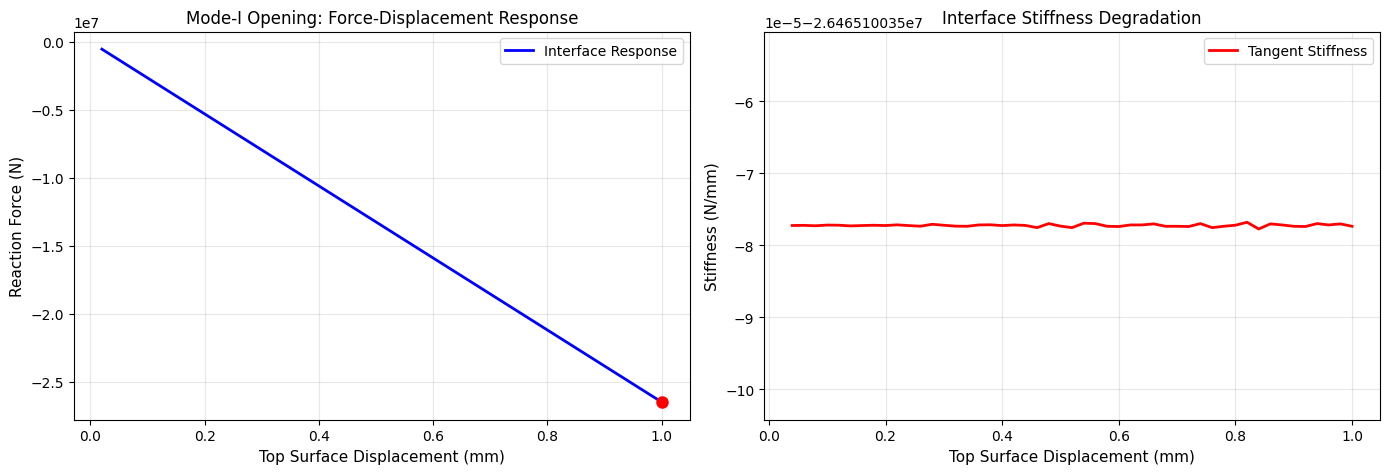


Plots saved as 'cohesive_interface_results.png'


In [8]:
if results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── Plot 1: Force-Displacement Curve ──────────────────
    ax = axes[0]
    disp = results['displacement'] * 1e3  # Convert to mm
    force = results['force']
    
    ax.plot(disp, force, 'b-', linewidth=2, label='Interface Response')
    ax.set_xlabel('Top Surface Displacement (mm)', fontsize=11)
    ax.set_ylabel('Reaction Force (N)', fontsize=11)
    ax.set_title('Mode-I Opening: Force-Displacement Response', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Add annotation for key points
    max_force_idx = np.argmax(np.abs(force))
    ax.plot(disp[max_force_idx], force[max_force_idx], 'ro', markersize=8, label='Peak')
    
    # ── Plot 2: Stiffness (slope) over time ───────────────
    ax = axes[1]
    # Compute tangent stiffness
    disp_nonzero = disp[1:]  # Skip first point
    force_nonzero = force[1:]
    stiffness = np.diff(force) / np.diff(disp)
    
    ax.plot(disp[1:], stiffness, 'r-', linewidth=2, label='Tangent Stiffness')
    ax.set_xlabel('Top Surface Displacement (mm)', fontsize=11)
    ax.set_ylabel('Stiffness (N/mm)', fontsize=11)
    ax.set_title('Interface Stiffness Degradation', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig('cohesive_interface_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPlots saved as 'cohesive_interface_results.png'")
    
else:
    print("No results to plot (analysis skipped or failed)")


## Deformed Mesh Visualization

Snapshots of the mesh at 5 equally-spaced load steps.  
Elements are coloured by vertical displacement **u_y**; the gap opening at the interface is visible as a separation between Block 1 and Block 2.  
Displacements are magnified by a scale factor for clarity.

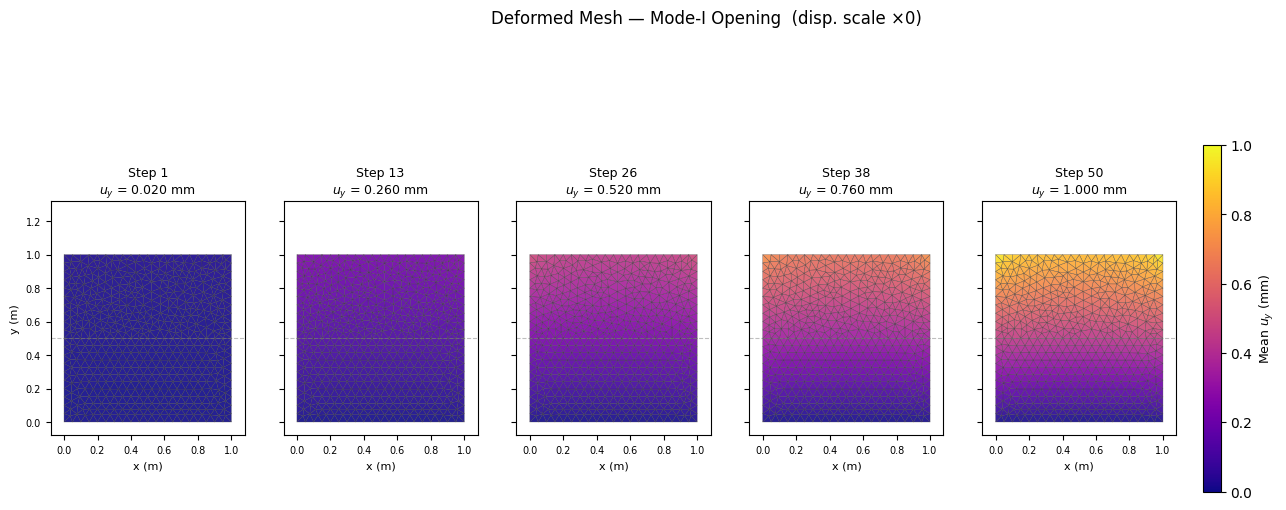

Saved → deformed_mesh_snapshots.png


In [9]:
from matplotlib.collections import PolyCollection

if results is not None and results.get('displacement_snapshots'):
    snapshots = results['displacement_snapshots']
    disp_arr  = results['displacement']

    # ── Build base-coordinate lookup for every node ───────────────────
    nodes_base = {int(gmsh_node_tags[i]): (gmsh_nodes[i, 0], gmsh_nodes[i, 1])
                  for i in range(len(gmsh_node_tags))}
    for dup_id, (x, y, _z) in dup_coords.items():
        nodes_base[dup_id] = (x, y)

    # ── Build polygon connectivity lists ──────────────────────────────
    def build_polys(elem_tags_list, elem_nodes_list):
        polys = []
        for etags, enodes in zip(elem_tags_list, elem_nodes_list):
            n_per = len(enodes) // len(etags)
            for row in enodes.reshape(-1, n_per):
                polys.append([int(n) for n in row])
        return polys

    b1_polys  = build_polys(gmsh_b1_elem_tags,  gmsh_b1_elem_nodes)
    b2_polys  = build_polys(gmsh_b2_elem_tags,  b2_elem_nodes_fixed)
    b1_ids    = [1] * len(b1_polys)   # 1 = Block 1
    b2_ids    = [2] * len(b2_polys)   # 2 = Block 2
    all_polys = b1_polys + b2_polys
    block_ids = b1_ids  + b2_ids

    # ── Scale factor: tune so the opening is clearly visible ─────────
    scale = max_displacement / (H1 + H2) * 80   # ~80× the engineering strain

    snap_keys = sorted(snapshots.keys())
    n_snaps   = len(snap_keys)

    fig, axes = plt.subplots(1, n_snaps, figsize=(3.5 * n_snaps, 6), sharey=True)
    if n_snaps == 1:
        axes = [axes]

    vmin = 0.0
    vmax = float(disp_arr.max()) if disp_arr.max() > 0 else 1e-6

    for ax, step_idx in zip(axes, snap_keys):
        snap = snapshots[step_idx]

        verts  = []
        colors = []
        for poly, blk in zip(all_polys, block_ids):
            pts  = []
            mean_uy = 0.0
            for nid in poly:
                x0, y0     = nodes_base[nid]
                ux, uy     = snap.get(nid, (0.0, 0.0))
                pts.append((x0 + scale * ux, y0 + scale * uy))
                mean_uy   += uy
            verts.append(pts)
            colors.append(mean_uy / len(poly))

        coll = PolyCollection(
            verts,
            array=np.array(colors),
            cmap='plasma',
            clim=(vmin, vmax),
            edgecolors='#444444',
            linewidths=0.25,
            alpha=0.90,
        )
        ax.add_collection(coll)

        # Draw cohesive gap: connect each interface pair with a thin line
        for pair in interface_pairs:
            n1, n2     = pair['node1'], pair['node2']
            x1, y1     = nodes_base[n1]
            x2, y2     = nodes_base[n2]
            ux1, uy1   = snap.get(n1, (0.0, 0.0))
            ux2, uy2   = snap.get(n2, (0.0, 0.0))
            ax.plot(
                [x1 + scale * ux1, x2 + scale * ux2],
                [y1 + scale * uy1, y2 + scale * uy2],
                color='red', linewidth=0.6, alpha=0.7,
            )

        # Axis formatting
        margin = 0.08
        ax.set_xlim(-margin, L1 + margin)
        ax.set_ylim(-margin, H1 + H2 + margin * 4)
        ax.set_aspect('equal')
        ax.axhline(y_interface, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

        uy_mm = disp_arr[step_idx] * 1e3
        ax.set_title(f'Step {step_idx + 1}\n$u_y$ = {uy_mm:.3f} mm', fontsize=9)
        ax.set_xlabel('x (m)', fontsize=8)
        if ax is axes[0]:
            ax.set_ylabel('y (m)', fontsize=8)
        ax.tick_params(labelsize=7)

    # Shared colourbar
    sm = plt.cm.ScalarMappable(cmap='plasma',
                                norm=plt.Normalize(vmin=vmin * 1e3, vmax=vmax * 1e3))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.75, pad=0.02)
    cbar.set_label('Mean $u_y$ (mm)', fontsize=9)

    fig.suptitle(f'Deformed Mesh — Mode-I Opening  (disp. scale ×{scale:.0f})',
                 fontsize=12, y=1.01)
    plt.savefig('deformed_mesh_snapshots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → deformed_mesh_snapshots.png")

else:
    print("No displacement snapshots available (run the analysis cell first).")

## Key Takeaways

### Interface Modeling Strategy
1. **Conformal Meshing**: Two separate surfaces with matching element sizes ensure node alignment at the interface.
2. **Node Pairing**: Nodes are identified by spatial coordinates and paired across the interface (either shared or duplicated).
3. **zeroLength Elements**: Connect paired nodes with penalty-based (elastic) or nonlinear cohesive materials.

### Cohesive Zone Representation
- **Normal Stiffness (Kn)**: Resistance to opening perpendicular to interface
- **Shear Stiffness (Ks)**: Resistance to sliding along interface
- **Tensile/Shear Strength**: Limits where damage/debonding initiates
- **Exponential or Bilinear**: Common shapes for traction-separation laws

### Extension to Real Cohesive Models
For more realistic cohesive behavior, implement:
1. **Damage Mechanics**: Track degradation as opening increases
2. **Mixed-Mode Criteria**: Combine normal + shear to determine failure
3. **Unloading Branches**: Capture permanent opening (residual deformation)
4. **Regularization**: Use energy-based (Gc) parameters instead of simple stiffness

### Practical Applications
- **Delamination**: Composite ply separation
- **Concrete-Rebar Bonding**: Bond-slip in reinforced concrete
- **Joint Modeling**: Concrete/mortar interfaces in masonry
- **Friction Interfaces**: Coulomb or other friction laws

This framework is extensible to 3D problems, multiple interfaces, and nonlinear material models.